In [28]:
import numpy as np
from sklearn.datasets import make_blobs
from dask import delayed
import dask.bag as db
import dask
import random
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [29]:
# import the dask distributed client
from dask.distributed import Client

# instantiate the client by providing 
# the address:port of the scheduler
client = Client('dask-scheduler:8786')

# inspect the client
client

<Client: 'tcp://172.19.0.2:8786' processes=2 threads=2, memory=0.95 GiB>

In [30]:
data = make_blobs(n_samples=500, n_features=2, centers=4)
samples = data[0]

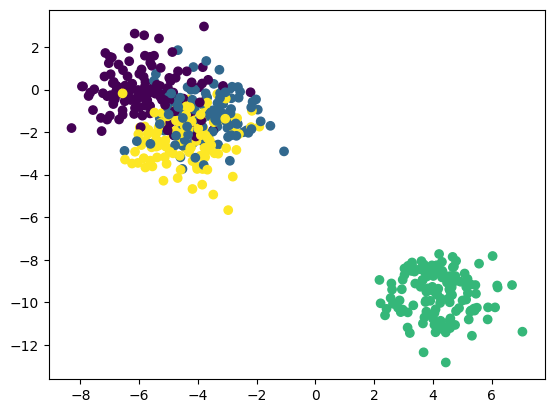

In [31]:
plt.scatter(samples[:,0], samples[:, 1], c=data[1])

In [32]:
X = db.from_sequence(data[0], npartitions=4)
x = data[0]
c = np.array([[0,0], [1, 1]])
centroids = c

In [33]:
d2 = X.map(lambda x: np.linalg.norm(x - c, axis=1) ** 2).map(lambda x: np.argmin(x))
d2.take(4)

(np.int64(0), np.int64(0), np.int64(0), np.int64(0))

In [42]:
class kmeans_parallel():
    def __init__(self, k, l):
        self.k = k
        self.l = l
        self.centroids = []

    def cost_function(self, X):
        centroids_arr = np.vstack(self.centroids)
        d2 = X.map(lambda x: np.min(np.linalg.norm(x - centroids_arr, axis=1) ** 2))
        return d2.sum().compute()


    def compute_probabilities(self, X, l, cost=None):
        centroids_arr = np.vstack(self.centroids)
        if cost is None:
            cost = self.cost_function(X)
        d2 = X.map(lambda x: np.min(np.linalg.norm(x - centroids_arr, axis=1) ** 2))
        # clip to 1 so it's a valid Bernoulli probability
        prob = d2.map(lambda d: min(1.0, d * l / cost))
        return prob
    
    def compute_weigths(self):
        centroids_arr = np.vstack(self.centroids)
        distances_from_centroids = X.map(lambda x: np.linalg.norm(x - centroids_arr, axis=1) ** 2)

        closer_centers_idxs = distances_from_centroids.map(lambda x: np.argmin(x))
        # the points in final set are few, can be stored on single machine
        counts = np.array(closer_centers_idxs.frequencies().compute())
        weights = np.zeros(len(self.centroids))

        # create weights where each element correspond to 
        # centroids in self.centroids
        for center_idx, count in counts:
            weights[center_idx] = count

        return np.array(weights)

    def fit(self, X, alpha=1, l=1):
        ######################################################
        # STEP 1
        # Filter down to roughly 1% of the data randomly on workers, 
        # then take the first one that passes the test.
        initial_centroid = X.filter(lambda x: random.random() < 0.01).take(1)[0] 
        initial_centroid = np.asarray(initial_centroid).reshape(1, -1)
        self.centroids.append(initial_centroid)

        ################################################
        # STEP 2
        psi = self.cost_function(X)

        #####################################################
        # STEP 3
        max_iter = int(round(alpha * np.log(psi)))

        for i in range(max_iter):
            cost = self.cost_function(X)
            probs = self.compute_probabilities(X, l, cost=cost)

            # sample directly in one lazy pass: pair each point with its prob,
            # keep it with probability prob, without a separate zip step
            paired = db.zip(X, probs)
            sample = (
                paired.filter(lambda t: np.random.uniform() < t[1])
                      .map(lambda t: t[0])
            ).compute()

            for s in sample:
                self.centroids.append(np.asarray(s).reshape(1, -1))

        ###################################################
        # STEP 7

        centroids_weights = self.compute_weigths()
        #print(centroids_weights)

        #####################################################à
        # STEP 8 usign scikit kmeans (few points, no need to parallize)

        kmeans = KMeans(n_clusters=self.k)
        kmeans.fit(np.vstack(self.centroids), sample_weight=centroids_weights)

        self.final_centroids = kmeans.cluster_centers_

In [43]:
clf = kmeans_parallel(k=4, l=1)
clf.fit(X)

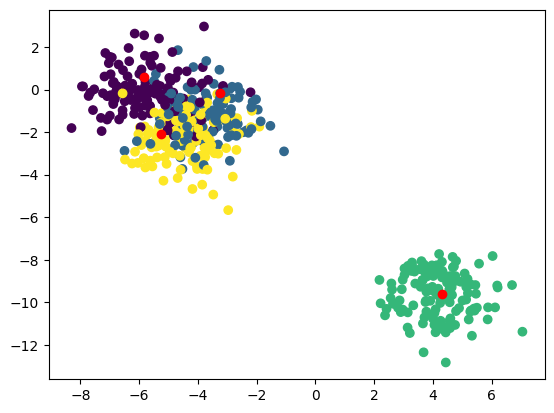

In [44]:
plt.scatter(samples[:,0], samples[:, 1], c=data[1])
plt.scatter(clf.final_centroids[:,0], clf.final_centroids[:,1], c="red")